In [1]:
from astropy.io import fits
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
import warnings
import os
import sys
from pathlib import Path
from useful_functions import *
import pickle

In [70]:
OII_rest    = lines_vac['OII']
NII_rest    = lines_vac['NII']
Hbeta_rest  = lines_vac['Hbeta']
Halpha_rest = lines_vac['Halpha']
SII_rest    = lines_vac['SII']
CaII_rest   = lines_vac['CaII']
NaD_rest    = lines_vac['NaD']
crop_region = [lines_vac['Halpha'][0]-30, lines_vac['Halpha'][0]+30]

spectra_data = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
spectra = Spectrum(spectra_data, color_data)

blue_crit = (spectra.color_criteria(criterion='g-z<1.25', exclude=True)) | (spectra.color_criteria(criterion='g-r<0.75', exclude=True))
qso_crit = spectra.subtype_criteria(subtype='QSO', exclude=True)
spectra.subset(criteria=blue_crit & qso_crit)
Fit = FitSpectrum(spectra)

Fit.shift_to_rest_frame()

In [71]:
save_path = './fitted_results_wo_z_adjust_diff_color.pkl'

records = []
if os.path.exists(save_path):
    with open(save_path, 'rb') as fin:
        while True:
            try:
                records.append(pickle.load(fin))
            except EOFError:
                break


# Searched NaD Absorption Lines

## Detection Rates

In [72]:
systematic_count = 0
inflow_count = 0
outflow_count = 0
no_detection_count = 0
for record in records:
    searched_NaD_type = record['NaD_type']
    if searched_NaD_type == 'systematic' or searched_NaD_type == 'systematic_2':
        systematic_count += 1
    elif searched_NaD_type == 'inflow' or searched_NaD_type == 'inflow_2':
        inflow_count += 1
    elif searched_NaD_type == 'outflow' or searched_NaD_type == 'outflow_2':
        outflow_count += 1
    else:
        no_detection_count += 1

print(f'Systematic: {systematic_count}, Inflow: {inflow_count}, Outflow: {outflow_count}, No Detection: {no_detection_count}')
print(f'NaD Detection Rate: {(systematic_count + inflow_count + outflow_count) / len(records) * 100:.2f}%')
print(f'Inflow Rate: {inflow_count / len(records) * 100:.2f}%')
print(f'Outflow Rate: {outflow_count / len(records) * 100:.2f}%')

Systematic: 2335, Inflow: 246, Outflow: 408, No Detection: 71938
NaD Detection Rate: 3.99%
Inflow Rate: 0.33%
Outflow Rate: 0.54%


In [73]:
inflow_ids = []
inflow_dlams = []
outflow_ids = []
outflow_dlams = []
for record in records:
    NaD_type = record['NaD_type']
    if (NaD_type == 'inflow') or (NaD_type == 'inflow_2'):
        inflow_ids.append(record['id'])
        inflow_dlams.append(record['NaD_params']['dlam'])
    elif (NaD_type == 'outflow') or (NaD_type == 'outflow_2'):
        outflow_ids.append(record['id'])
        outflow_dlams.append(record['NaD_params']['dlam'])

In [74]:
print(inflow_dlams)
print(inflow_ids)

[np.float64(1.242093088572024), np.float64(1.444128925283775), np.float64(0.9084953217664967), np.float64(0.8163569927785332), np.float64(1.1612004040846733), np.float64(1.150607772005782), np.float64(0.9647538650486881), np.float64(1.185977732363917), np.float64(0.8151736480874474), np.float64(1.1258275482515385), np.float64(0.9342484765575418), np.float64(1.1059930894380967), np.float64(1.8577672187498158), np.float64(1.3539853918746316), np.float64(0.9335045900347885), np.float64(1.394910612779208), np.float64(1.1241822045293035), np.float64(1.0452737874661495), np.float64(1.1424145113551103), np.float64(1.8117368122015411), np.float64(1.032633136504858), np.float64(1.4133224460376876), np.float64(0.9317731905997936), np.float64(1.1596818271548848), np.float64(0.9825041388992035), np.float64(1.236225123905394), np.float64(3.020010011603575), np.float64(1.0649609725384117), np.float64(2.64791644583267), np.float64(0.8457155234049802), np.float64(0.8161336933821411), np.float64(2.2464

In [75]:
print(outflow_dlams)
print(outflow_ids)

[np.float64(-0.9300622016928164), np.float64(-0.9099189589723412), np.float64(-0.804907743037699), np.float64(-0.9667388412623021), np.float64(-0.8633042978537578), np.float64(-1.2754967662734058), np.float64(-0.9902310888012446), np.float64(-1.5871528758159457), np.float64(-0.8483298877359473), np.float64(-1.3561188596502733), np.float64(-1.1657360674915787), np.float64(-4.999999999105296), np.float64(-4.999999999999999), np.float64(-0.9894194242254171), np.float64(-1.5382815652761814), np.float64(-1.2212434518534587), np.float64(-0.8117617645134386), np.float64(-0.8566799399653856), np.float64(-0.8960595722643016), np.float64(-1.8682213933874667), np.float64(-1.2117131243259622), np.float64(-1.1590957326162659), np.float64(-0.8624852980608845), np.float64(-1.5956694192118455), np.float64(-3.671861109309957), np.float64(-0.9647327553518706), np.float64(-1.3366153247818178), np.float64(-1.04792729705886), np.float64(-1.0424170127645003), np.float64(-0.8785918035091309), np.float64(-0.8

In [76]:
dlam_inflow_max_idx = np.argmax(inflow_dlams)
print(f'Max Inflow dlam: {inflow_dlams[dlam_inflow_max_idx]} for ID {inflow_ids[dlam_inflow_max_idx]}')
dlam_outflow_max_idx = np.argmin(outflow_dlams)
print(f'Max Outflow dlam: {outflow_dlams[dlam_outflow_max_idx]} for ID {outflow_ids[dlam_outflow_max_idx]}')

Max Inflow dlam: 4.1685407240422325 for ID 39627739812074328
Max Outflow dlam: -4.999999999999999 for ID 39627800251995656


## Inflow Demo

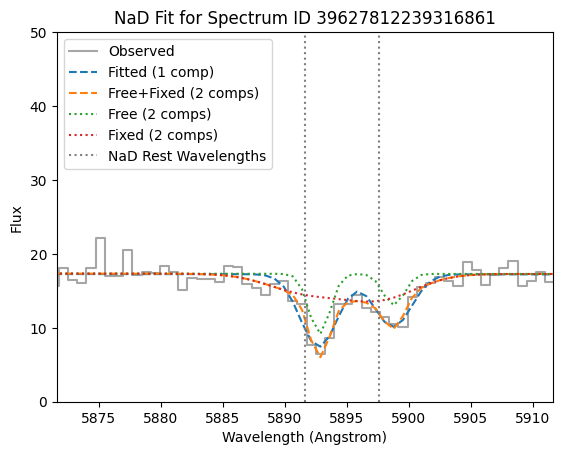

In [108]:
idx = Fit.id2index(39627812239316861)

params_s, status_s = Fit.fit_flux(id=Fit.targetID[idx], lam0=[*NaD_rest], two_component=False, fit_z=False, e_or_a='a')
fitted_model_s = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_s['gaussian_params'], conti_parms=params_s['conti_params'])

params_d, status_d = Fit.fit_flux(id=Fit.targetID[idx], lam0=[*NaD_rest], two_component=True, fit_z=False, e_or_a='a')
fitted_model_d = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['gaussian_params'], conti_parms=params_d['conti_params'])
free_model = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['free_comps'], conti_parms=params_d['conti_params'])
fixed_model = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['fixed_comps'], conti_parms=params_d['conti_params'])

crop_region = [lines_vac['NaD'][0]-20, lines_vac['NaD'][0]+20]
plt.step(Fit.data_stack[idx, 0, :], Fit.data_stack[idx, 1, :], label='Observed', where='mid', color='gray', alpha=0.7)
plt.plot(Fit.data_stack[idx, 0, :], fitted_model_s, label='Fitted (1 comp)', linestyle='--')
plt.plot(Fit.data_stack[idx, 0, :], fitted_model_d, label='Free+Fixed (2 comps)', linestyle='--')
plt.plot(Fit.data_stack[idx, 0, :], free_model, label='Free (2 comps)', linestyle=':')
plt.plot(Fit.data_stack[idx, 0, :], fixed_model, label='Fixed (2 comps)', linestyle=':')
plt.axvline(x=NaD_rest[0], color='gray', linestyle=':', label='NaD Rest Wavelengths')
plt.axvline(x=NaD_rest[1], color='gray', linestyle=':')
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.title(f'NaD Fit for Spectrum ID {Fit.targetID[idx]}')
plt.legend()
plt.xlim(crop_region)
plt.ylim(bottom=0, top=50)
plt.show()

## Outflow Demo

In [109]:
# idx = Fit.id2index(39627770073975211)

# params_s, status_s = Fit.fit_flux(id=Fit.targetID[idx], lam0=[*NaD_rest], two_component=False, fit_z=False, e_or_a='a')
# print(params_s['dlam']*c/NaD_rest[0])
# fitted_model_s = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_s['gaussian_params'], conti_parms=params_s['conti_params'])

# params_d, status_d = Fit.fit_flux(id=Fit.targetID[idx], lam0=[*NaD_rest], two_component=True, fit_z=False, e_or_a='a')
# print(params_d['dlam']/NaD_rest[0]*c)
# fitted_model_d = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['gaussian_params'], conti_parms=params_d['conti_params'])
# free_model = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['free_comps'], conti_parms=params_d['conti_params'])
# fixed_model = model(Fit.data_stack[idx, 0, :], gaussian_parms=params_d['fixed_comps'], conti_parms=params_d['conti_params'])

# crop_region = [lines_vac['NaD'][0]-10, lines_vac['NaD'][0]+20]
# plt.step(Fit.data_stack[idx, 0, :], Fit.data_stack[idx, 1, :], label='Observation', where='mid', color='gray', alpha=0.7)
# # plt.plot(Fit.data_stack[idx, 0, :], fitted_model_s, label='Fitted (1 comp)', linestyle='--')
# plt.plot(Fit.data_stack[idx, 0, :], fitted_model_d, label='Free+Fixed (2 comps)', linestyle='-', linewidth=3)
# plt.plot(Fit.data_stack[idx, 0, :], free_model, label='Free (2 comps)', linestyle='--', linewidth=2)
# plt.plot(Fit.data_stack[idx, 0, :], fixed_model, label='Fixed (2 comps)', linestyle='--', linewidth=2)
# plt.axvline(x=NaD_rest[0], color='gray', linestyle=':', label='NaD Rest Wavelengths')
# plt.axvline(x=NaD_rest[1], color='gray', linestyle=':')
# plt.xlabel('Wavelength (Angstrom)')
# plt.ylabel('Flux')
# plt.title(f'NaD Fit for Spectrum ID {Fit.targetID[idx]}')
# plt.legend()
# plt.xlim(crop_region)
# # plt.ylim(bottom=0, top=15)
# plt.savefig('./figures/Nov5/two_comp_nad_demo_inflow.png')
# plt.show()


# plt.step(Fit.data_stack[idx, 0, :], Fit.data_stack[idx, 1, :], label='Observation', where='mid', color='gray', alpha=0.7)
# plt.plot(Fit.data_stack[idx, 0, :], fitted_model_s, label='Fitted model (1 comp)', linestyle='-', linewidth=3)
# plt.axvline(x=NaD_rest[0], color='gray', linestyle=':', label='NaD Rest Wavelengths')
# plt.axvline(x=NaD_rest[1], color='gray', linestyle=':')
# plt.xlabel('Wavelength (Angstrom)')
# plt.ylabel('Flux')
# plt.title(f'NaD Fit for Spectrum ID {Fit.targetID[idx]}')
# plt.legend()
# plt.xlim(crop_region)
# # plt.ylim(bottom=0, top=15)
# plt.savefig('./figures/Nov5/one_comp_nad_demo_inflow.png')
# plt.show()


In [110]:
RA, DEC = Fit.RA[idx], Fit.DEC[idx]
image_link(RA, DEC, save_image=True, fname='./figures/Nov5/nad_demo_image.jpg')

Saved ./figures/Nov5/nad_demo_image.jpg


'https://www.legacysurvey.org/viewer?ra=199.99746232226602&dec=0.9521542913744835&layer=ls-dr10-grz&zoom=14'